In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
SUMMARY_JSONL = "/root/exp/kd_project_eval/eval_summary.jsonl"

In [3]:
rows = []
with open(SUMMARY_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

flat_rows = []
for r in rows:
    flat = {
        "run_name": r.get("run_name"),
        "num_examples": r.get("num_examples"),
        "norm_em": r.get("normalized_exact_match"),
        "f1": r.get("token_overlap_f1"),
        "resp_nll": r.get("response_nll"),
        "resp_ppl": r.get("response_ppl"),
        "student_conf": r.get("student_mean_confidence"),
        "teacher_entropy": r.get("teacher_mean_entropy", None),

        "low_f1": r.get("low_entropy_bucket", {}).get("token_overlap_f1"),
        "mid_f1": r.get("mid_entropy_bucket", {}).get("token_overlap_f1"),
        "high_f1": r.get("high_entropy_bucket", {}).get("token_overlap_f1"),

        "low_nll": r.get("low_entropy_bucket", {}).get("response_nll"),
        "mid_nll": r.get("mid_entropy_bucket", {}).get("response_nll"),
        "high_nll": r.get("high_entropy_bucket", {}).get("response_nll"),
    }
    flat_rows.append(flat)

df = pd.DataFrame(flat_rows)

# 打印表
print(df.to_string(index=False))

    run_name  num_examples  norm_em       f1  resp_nll  resp_ppl  student_conf  teacher_entropy   low_f1   mid_f1  high_f1  low_nll  mid_nll  high_nll
sft_baseline          1000    0.000 0.415393  0.880408  2.671496      0.751246         0.566993 0.460215 0.413937 0.371765 0.469125 0.894619  1.279873
 kd_baseline          1000    0.007 0.446657  0.927272  2.817822      0.770410         0.566993 0.548414 0.422620 0.368470 0.507952 0.947368  1.328902
 ukd_entropy          1000    0.004 0.442897  0.921185  2.800142      0.774879         0.566993 0.531196 0.423572 0.373508 0.503710 0.940857  1.321383


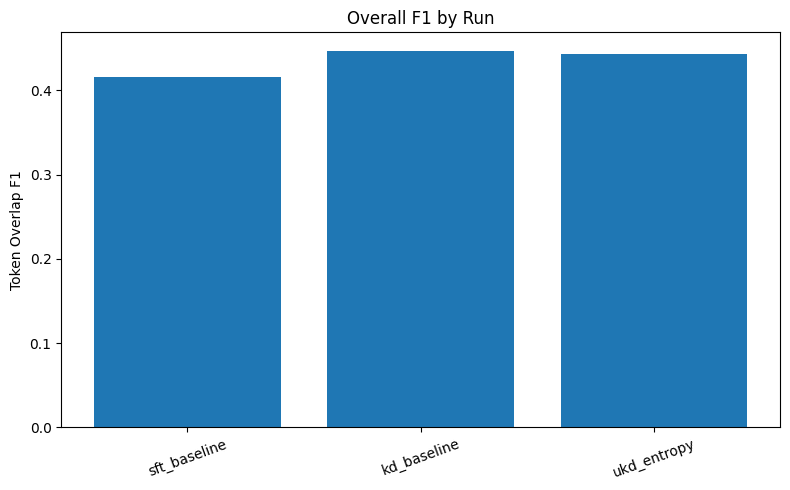

In [4]:
# -----------------------------
# 图1：overall F1
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(df["run_name"], df["f1"])
plt.ylabel("Token Overlap F1")
plt.title("Overall F1 by Run")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

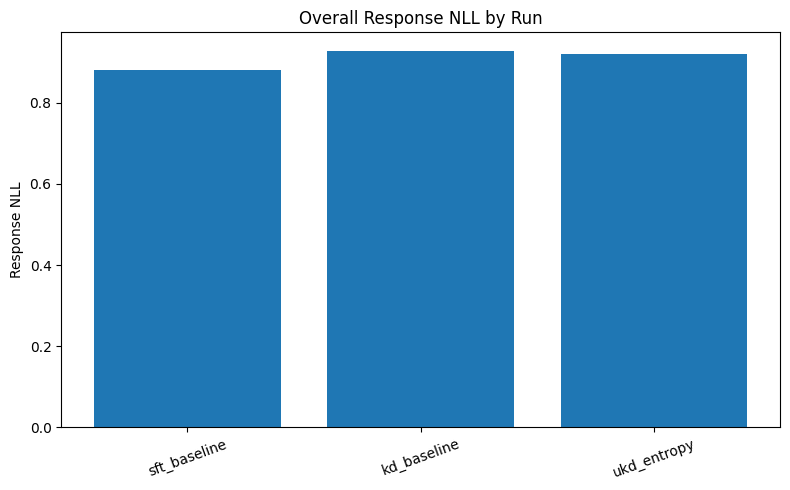

In [5]:
# -----------------------------
# 图2：overall response NLL
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(df["run_name"], df["resp_nll"])
plt.ylabel("Response NLL")
plt.title("Overall Response NLL by Run")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

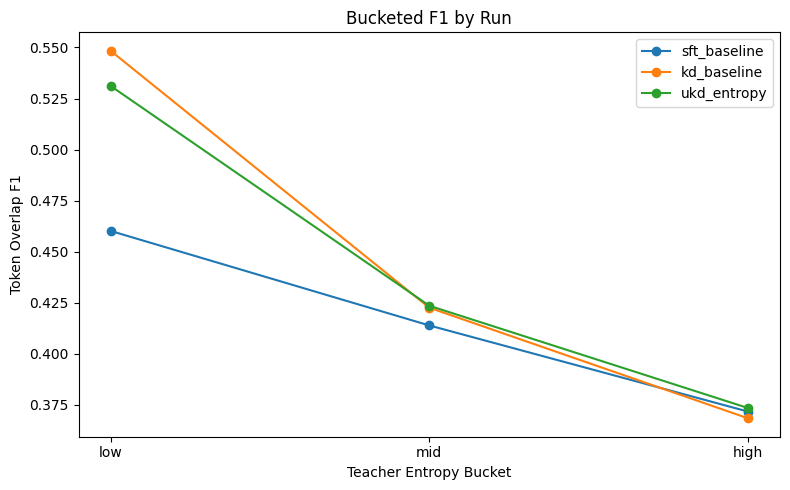

In [6]:
# -----------------------------
# 图3：bucketed F1
# -----------------------------
bucket_order = ["low_f1", "mid_f1", "high_f1"]
bucket_labels = ["low", "mid", "high"]

plt.figure(figsize=(8, 5))
for _, row in df.iterrows():
    ys = [row[c] for c in bucket_order]
    plt.plot(bucket_labels, ys, marker="o", label=row["run_name"])

plt.xlabel("Teacher Entropy Bucket")
plt.ylabel("Token Overlap F1")
plt.title("Bucketed F1 by Run")
plt.legend()
plt.tight_layout()
plt.show()

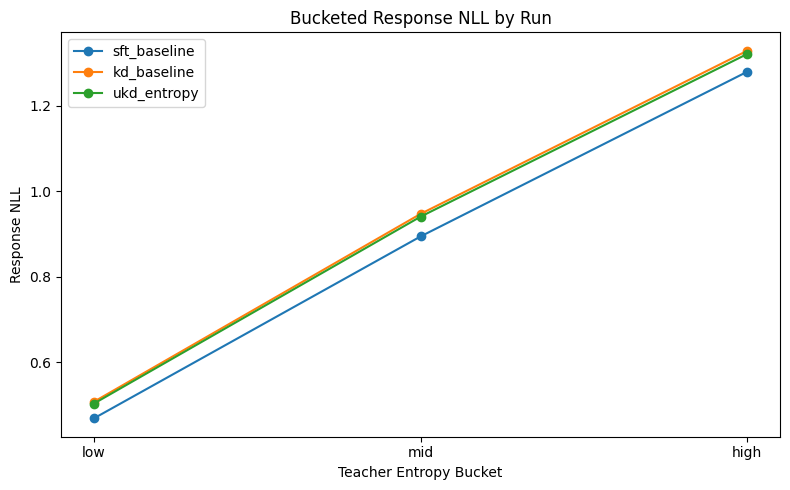

In [7]:
# -----------------------------
# 图4：bucketed NLL
# -----------------------------
bucket_order_nll = ["low_nll", "mid_nll", "high_nll"]

plt.figure(figsize=(8, 5))
for _, row in df.iterrows():
    ys = [row[c] for c in bucket_order_nll]
    plt.plot(bucket_labels, ys, marker="o", label=row["run_name"])

plt.xlabel("Teacher Entropy Bucket")
plt.ylabel("Response NLL")
plt.title("Bucketed Response NLL by Run")
plt.legend()
plt.tight_layout()
plt.show()